In [1]:
import importlib
import sys
sys.path.append('../code')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import Kyrafunctions as ky

import SeaLevelContrib as slc

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [2]:
importlib.reload(slc)

<module 'SeaLevelContrib' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\../code\\SeaLevelContrib.py'>

In [3]:
data_path = '../data/GravIs/'

In [4]:
# Maak jaarlijkse dataset: 

#Antarctica: 
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
ant_y = ky.yearlygrace(ant) 

#Greenland: 
gre = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_GIS_GRID_TUD_0003.nc")
gre_y = ky.yearlygrace(gre) 

#display(ant_y)

In [5]:
Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_clean.nc')
Gravis_gre_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Gre_clean.nc')

#Optional: scale data by factor 1.2 or 1.1837950465122913
Gravis_ant_ds['IS_Gravis'] = Gravis_ant_ds['IS_Gravis']*1.1837950465122913
Gravis_ant_ds['Meanslr'] = Gravis_ant_ds['Meanslr']*1.1837950465122913

#display(Gravis_ant_ds)
#display(Gravis_gre_ds)
#Gravis_ant_ds['IS_Gravis'].isel(time=-1).plot()

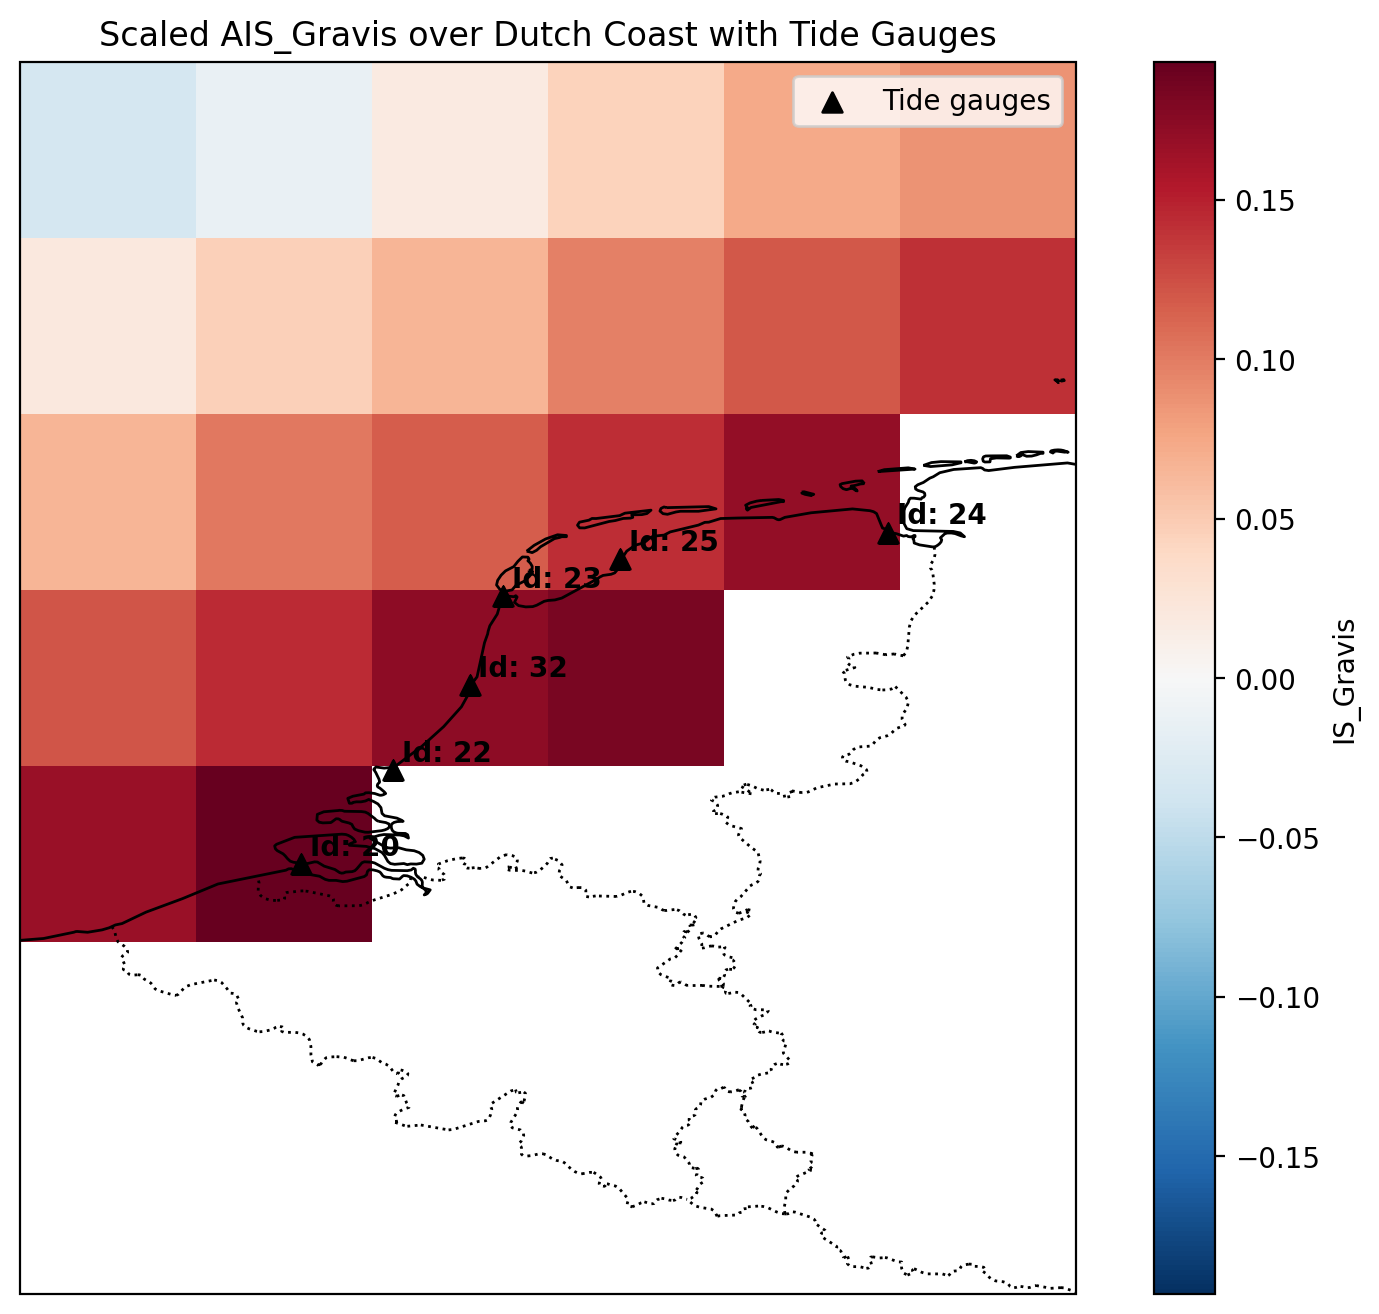

In [6]:
tg_id = [20, 22, 23, 24, 25, 32]
#Extract latitude and longitude from a tide gauge station from the list. 
tg_coord = slc.tg_lat_lon(tg_id[0])
#print(tg_coord)

# Extract coordinates
tg_coords = [slc.tg_lat_lon(tg) for tg in tg_id]
tg_lats = [c[0] for c in tg_coords]
tg_lons = [c[1] for c in tg_coords]

# Define region (Dutch coast)
lon_min, lon_max = 2,8 #3, 7
lat_min, lat_max = 49, 56 #51, 54

# Select region
da_region = Gravis_gre_ds['IS_Gravis'].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)

# Pick a specific time if dataset has time dimension
if 'time' in da_region.dims:
    da_region = da_region.isel(time=-1)#-da_region.isel(time=0)  # Last time step minus first timestep (first timestep is already 0 so no need for that) 

# Plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot GRAVIS data
im = da_region.plot(ax=ax, cmap='RdBu_r', add_colorbar=True)

# Add coastlines and borders
ax.coastlines(resolution='10m', zorder = 1 )
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot tide gauge stations
ax.scatter(tg_lons, tg_lats, color='black', s=50, marker='^', label='Tide gauges', zorder=10)

# Add tide gauge IDs as labels
for lon, lat, tg in zip(tg_lons, tg_lats, tg_id):
    ax.text(lon + 0.05, lat + 0.05, 'Id: ' + str(tg), color='black', fontsize=10, weight='bold', zorder=10)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title('Scaled AIS_Gravis over Dutch Coast with Tide Gauges')
ax.legend()

plt.show()


Since station 22 does not overlap with sea for this landsea mask, the sea level rise at the location of this station will set to zero. For now, the value of station 32 is used there for computing the mean.  

In [7]:
## load file with rise antarctica to calculate the fraction: 
tg_id = [20, 22, 23, 24, 25, 32] #tg stations to calculate the mean @dutch coast #use 23 in stead of 22 for now 

all_GRAVANT = []
all_GRAVGRE = []

for tg in tg_id: 
    tg_coord = slc.tg_lat_lon(tg)
    sel_da = Gravis_ant_ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    sel_da_gre = Gravis_gre_ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
    loc_da_gre = sel_da_gre.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

    fr_name = {
        'tws' : 'TWS', 
        'AIS' : 'Antarctica', 
        'GrIS' : 'Greenland', 
        'glac' : 'Glaciers',
        'grav': 'Ant_gravis',
        'grav2': 'Gre_gravis'}
 
    GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav']) 
    GRAVGRE = loc_da_gre.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav2'])  
    #print(f'tgid{tg}')
    #display(GRAVANT)
    all_GRAVANT.append(GRAVANT)
    all_GRAVGRE.append(GRAVGRE)


# Compute mean of tide gauges: 

def mean_across_gauges(list_of_series):
    return pd.concat(list_of_series, axis=1).mean(axis=1)

# Compute mean time series for each contribution
mean_GRAVANT = mean_across_gauges(all_GRAVANT)
mean_GRAVGRE = mean_across_gauges(all_GRAVGRE)

# Combine all mean series into a single dataframe
mean_df = pd.DataFrame({
    #'Antarctica_mean': mean_ANT,
   # 'Greenland_mean': mean_GRE,
    'Ant_gravis_mean': mean_GRAVANT,
    'Gre_gravis_mean': mean_GRAVGRE
})


# Ensure the index is numeric or datetime
mean_df.index = pd.to_numeric(mean_df.index, errors='coerce')


#display(all_GRAVANT)
display(mean_df)

,Ant_gravis_mean,Gre_gravis_mean
time,,
2002,0.000000,0.000000
2003,0.029048,0.009851
2004,0.059572,0.013824
2005,0.070121,0.011643
2006,0.058111,0.015205
2007,0.101027,0.019718
2008,0.183176,0.032020
2009,0.168140,0.044154
2010,0.218463,0.054499


In [8]:
print(type(mean_df['Ant_gravis_mean']))
print(type(Gravis_ant_ds['Meanslr']))

<class 'pandas.core.series.Series'>
<class 'xarray.core.dataarray.DataArray'>


In [9]:
# Fraction cummulative data:
dutch_coast = mean_df['Gre_gravis_mean'] # dutch coast raw values - factor 1.2 is used. 
mean_world = Gravis_gre_ds['Meanslr'].to_series()  #this is now a data array but to make sure it works thte same translate it to a series , factor 1.2 is used 
fraction = dutch_coast/mean_world

display(mean_world)

# Fractom using yearly data: 
dutch_c = dutch_coast.diff()  # dutch coast per year
mean_w = mean_world.diff() #global mean per year 
fractionperyear = dutch_c/mean_w

# Cummulative data running mean: 
dutch_coast_5y = dutch_coast.rolling(window=5, center=True).mean()   #min periods=1 uses less data at the boundaries
mean_world_5y   = mean_world.rolling(window=5, center=True).mean()
fraction_5y = dutch_coast_5y/mean_world_5y

# Yearly data running
dutch_c_5y =  dutch_c.rolling(window=5, center=True).mean() 
mean_w_5y =  mean_w.rolling(window=5, center=True).mean()
fractionperyearrun = dutch_c_5y/mean_w_5y

# Yearly data running method 2
dutrun = dutch_coast_5y.diff()   #min periods=1 uses less data at the boundaries
worldrun = mean_world_5y.diff()
peryearfrac = dutrun/worldrun



combined2= pd.DataFrame({
   # 'Dutch coast': dutch_coast, 
   # 'Global mean sea level rise': mean_world,
   # 'Fraction (Dutch/global mean )': fraction,

   # 'Dutch coast running mean 5y': dutch_coast_5y,
   # 'Global running mean 5y': mean_world_5y, 
   # 'Fraction using running means': fraction_5y,
    
   # 'Dutch absolute': dutch_c,
   # 'Global absoolute': mean_w,
   # 'Fraction per year': fractionperyear,
    
    'Dutch absolute running': dutch_c_5y, 
    'Global mean absolute running 5y': mean_w_5y,
    'Fraction running per year': fractionperyearrun
})

display(combined2)


# --- Styling parameters ---
def highlight_fraction_cols(s):
    """Highlights columns with 'Fraction' in their name."""
    is_fraction = 'Fraction' in s.name
    return ['background-color: lightyellow' if is_fraction else '' for _ in s]

# --- CSS Styles for visual grouping ---
# 1. Border after the 1st column ('Dutch coast') to exclude it from the main grouping.
# 2. Borders after columns 4, 7, and 10 to group the remaining 11 columns into (3, 3, 3, 2).
#    (These columns are Global, Fraction, Dutch)
styles = [
    # Border after the 1st column (excluding it from the main 3-grouping)
    {'selector': 'th.col_heading.level0:nth-child(1)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(1)', 'props': [('border-right', '3px solid #666666')]},

    # Borders after the 4th, 7th, and 10th columns to create the triplets
    # (Global mean SL, Fraction, Dutch coast running mean 5y) and subsequent groups
    {'selector': 'th.col_heading.level0:nth-child(4)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(4)', 'props': [('border-right', '3px solid #666666')]},
    
    {'selector': 'th.col_heading.level0:nth-child(7)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(7)', 'props': [('border-right', '3px solid #666666')]},
    
    {'selector': 'th.col_heading.level0:nth-child(10)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(10)', 'props': [('border-right', '3px solid #666666')]}
]

combined2_2005 = combined2.loc[2005:] 

# --- Apply the Styling ---
styled_combined2_2005 = (
    combined2_2005.style
    # Apply the highlighting to the Fraction columns
    .apply(highlight_fraction_cols, axis=0) 
    # Apply the visual grouping borders
    .set_table_styles(styles)
    # Format all numeric columns to 4 decimal places
    .format('{:.4f}')
)

# --- Display the styled table ---
display(styled_combined2_2005)


time
2002    0.000000
2003    0.014190
2004    0.065368
2005    0.113737
2006    0.174350
2007    0.237355
2008    0.305346
2009    0.358210
2010    0.441327
2011    0.558425
2012    0.655085
2013    0.730407
2014    0.767634
2015    0.805737
2016    0.860845
2017    0.874094
2018    0.934749
2019    1.004766
2020    1.106300
2021    1.146015
2022    1.186783
2023    1.229060
2024    1.269202
Name: Meanslr, dtype: float64

,Dutch absolute running,Global mean absolute running 5y,Fraction running per year
time,,,
2002,NaN,NaN,NaN
2003,NaN,NaN,NaN
2004,NaN,NaN,NaN
2005,0.003944,0.047471,0.083075
2006,0.004434,0.058231,0.076140
2007,0.006066,0.058568,0.103572
2008,0.008571,0.065518,0.130823
2009,0.010059,0.076815,0.130955
2010,0.011751,0.083546,0.140656


,Dutch absolute running,Global mean absolute running 5y,Fraction running per year
time,,,
2005,0.0039,0.0475,0.0831
2006,0.0044,0.0582,0.0761
2007,0.0061,0.0586,0.1036
2008,0.0086,0.0655,0.1308
2009,0.0101,0.0768,0.1310
2010,0.0118,0.0835,0.1407
2011,0.0109,0.0850,0.1280
2012,0.0099,0.0819,0.1209
2013,0.0101,0.0729,0.1388


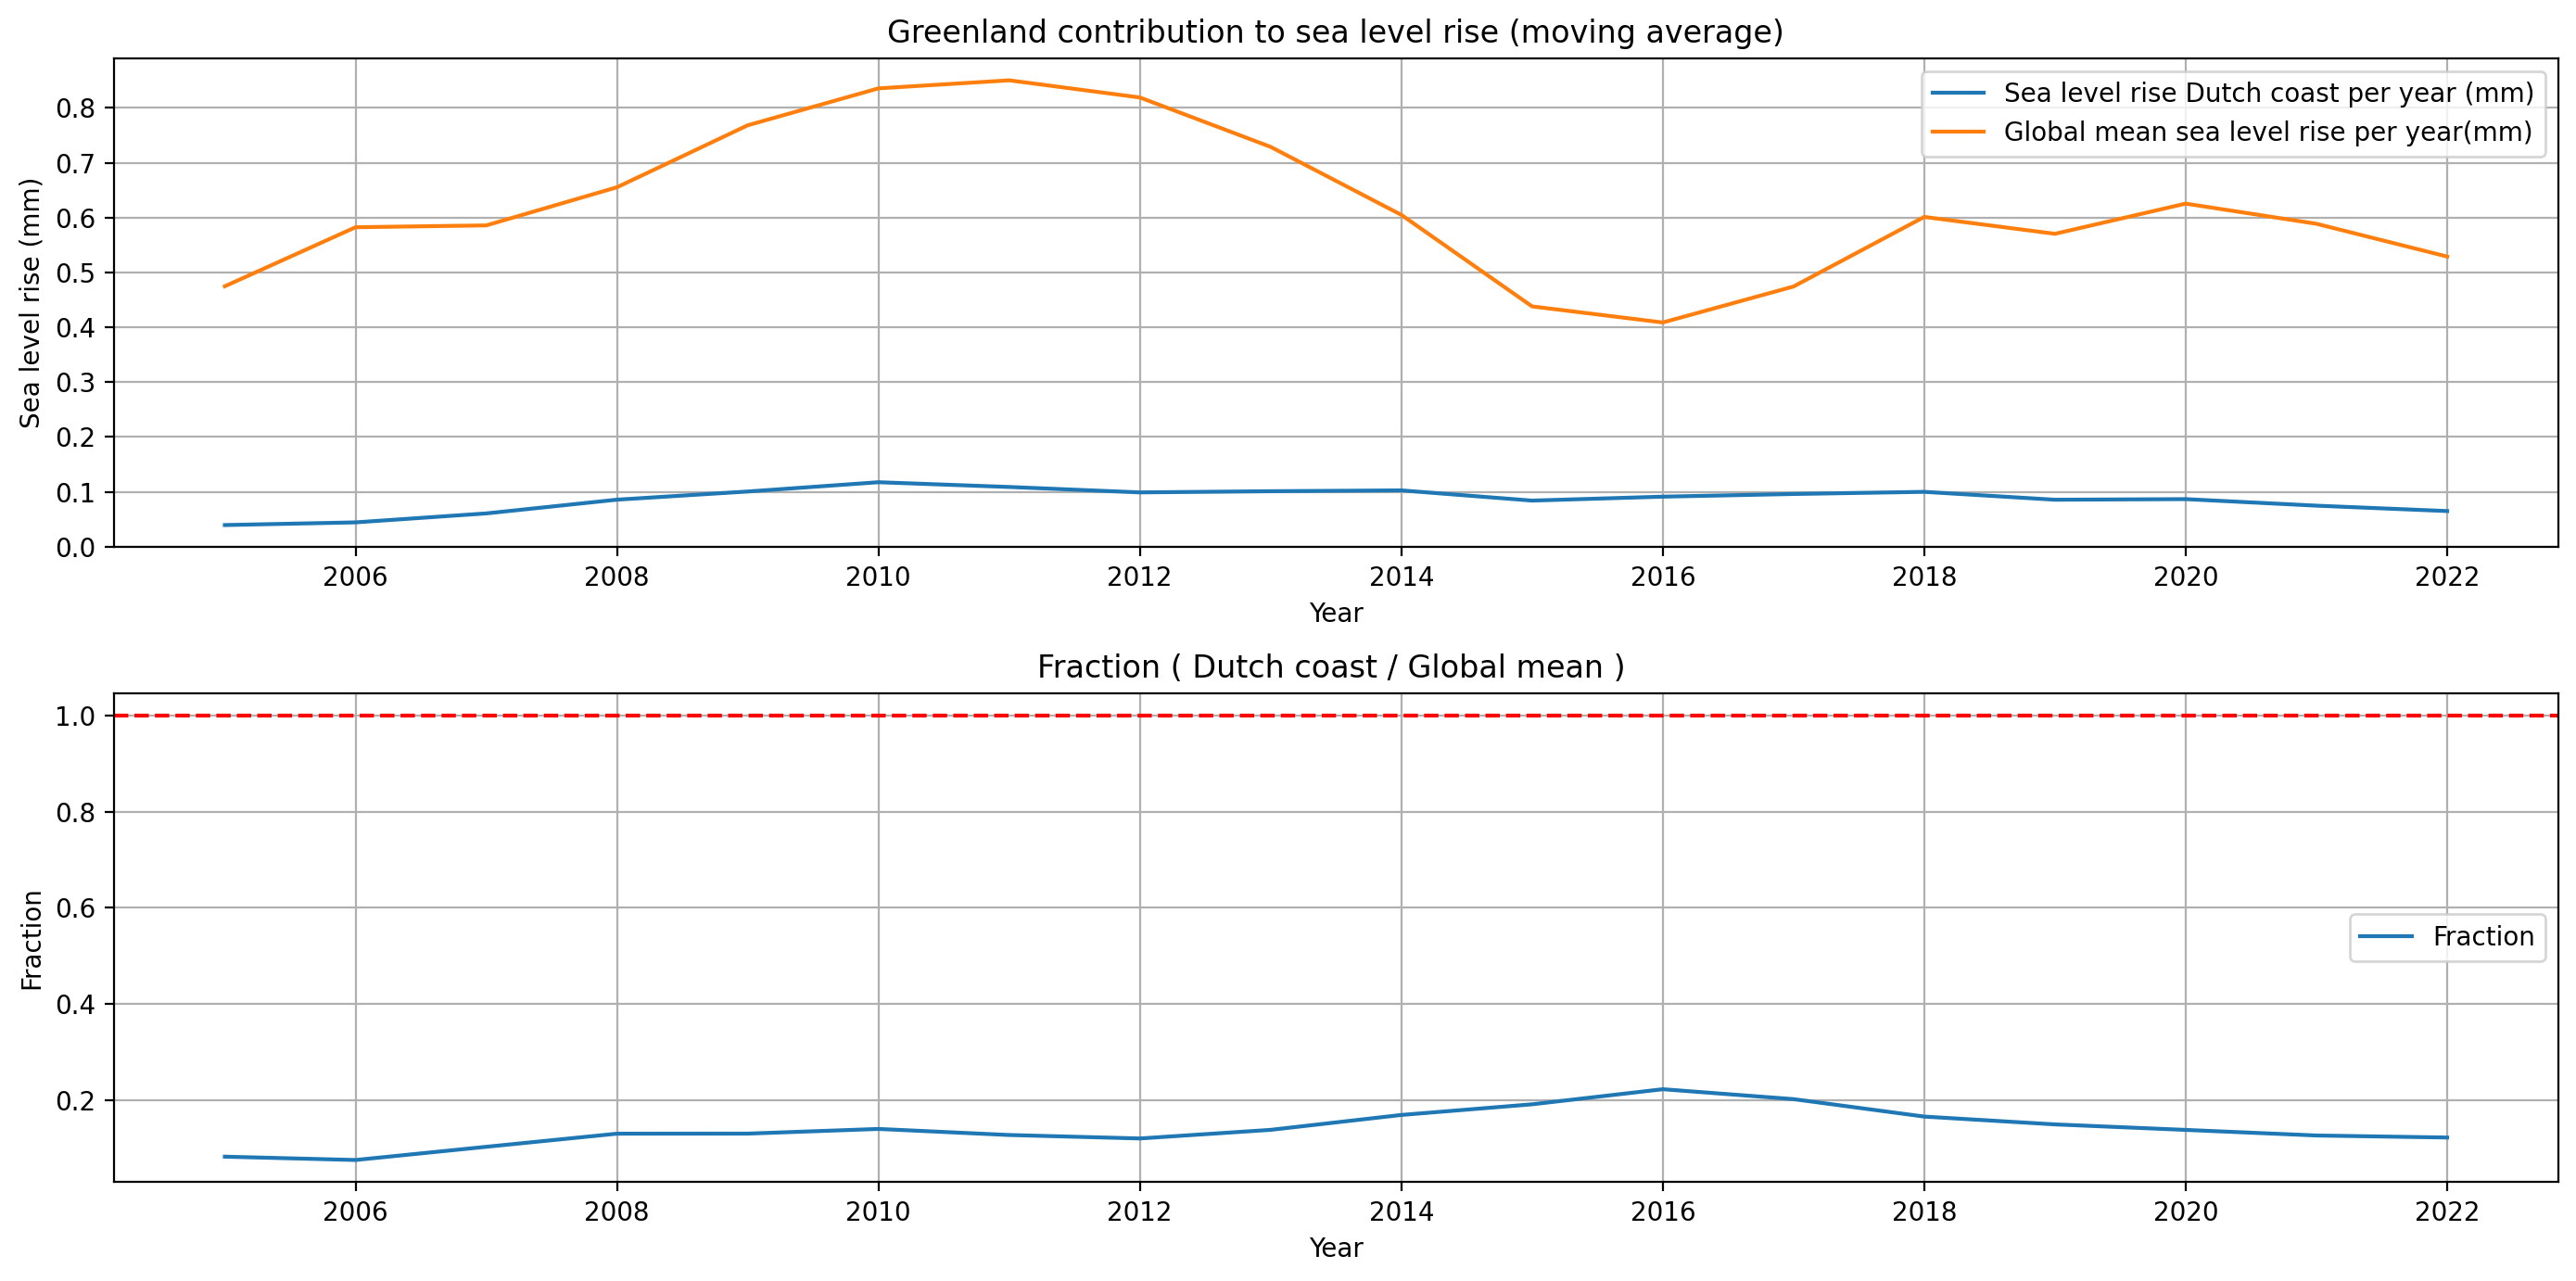

In [21]:
from matplotlib.ticker import MaxNLocator

# Plot the two different figures in one window (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

#Plot1
(dutch_c_5y*10).plot(ax=ax1, label='Sea level rise Dutch coast per year (mm)')  #translated to mm
(mean_w_5y*10).plot(ax=ax1, label='Global mean sea level rise per year(mm)')

ax1.set_title("Greenland contribution to sea level rise (moving average)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Sea level rise (mm)")
ax1.legend()
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # whole numbers
ax1.grid()

# Plot2
fractionperyearrun.plot(ax=ax2, label='Fraction')
ax2.axhline(y=1, color='r', linestyle='--')

ax2.set_title("Fraction ( Dutch coast / Global mean ) ")
ax2.set_xlabel("Year")
ax2.set_ylabel("Fraction")
ax2.legend()
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))  # whole numbers
ax2.grid()

plt.tight_layout()
plt.show()


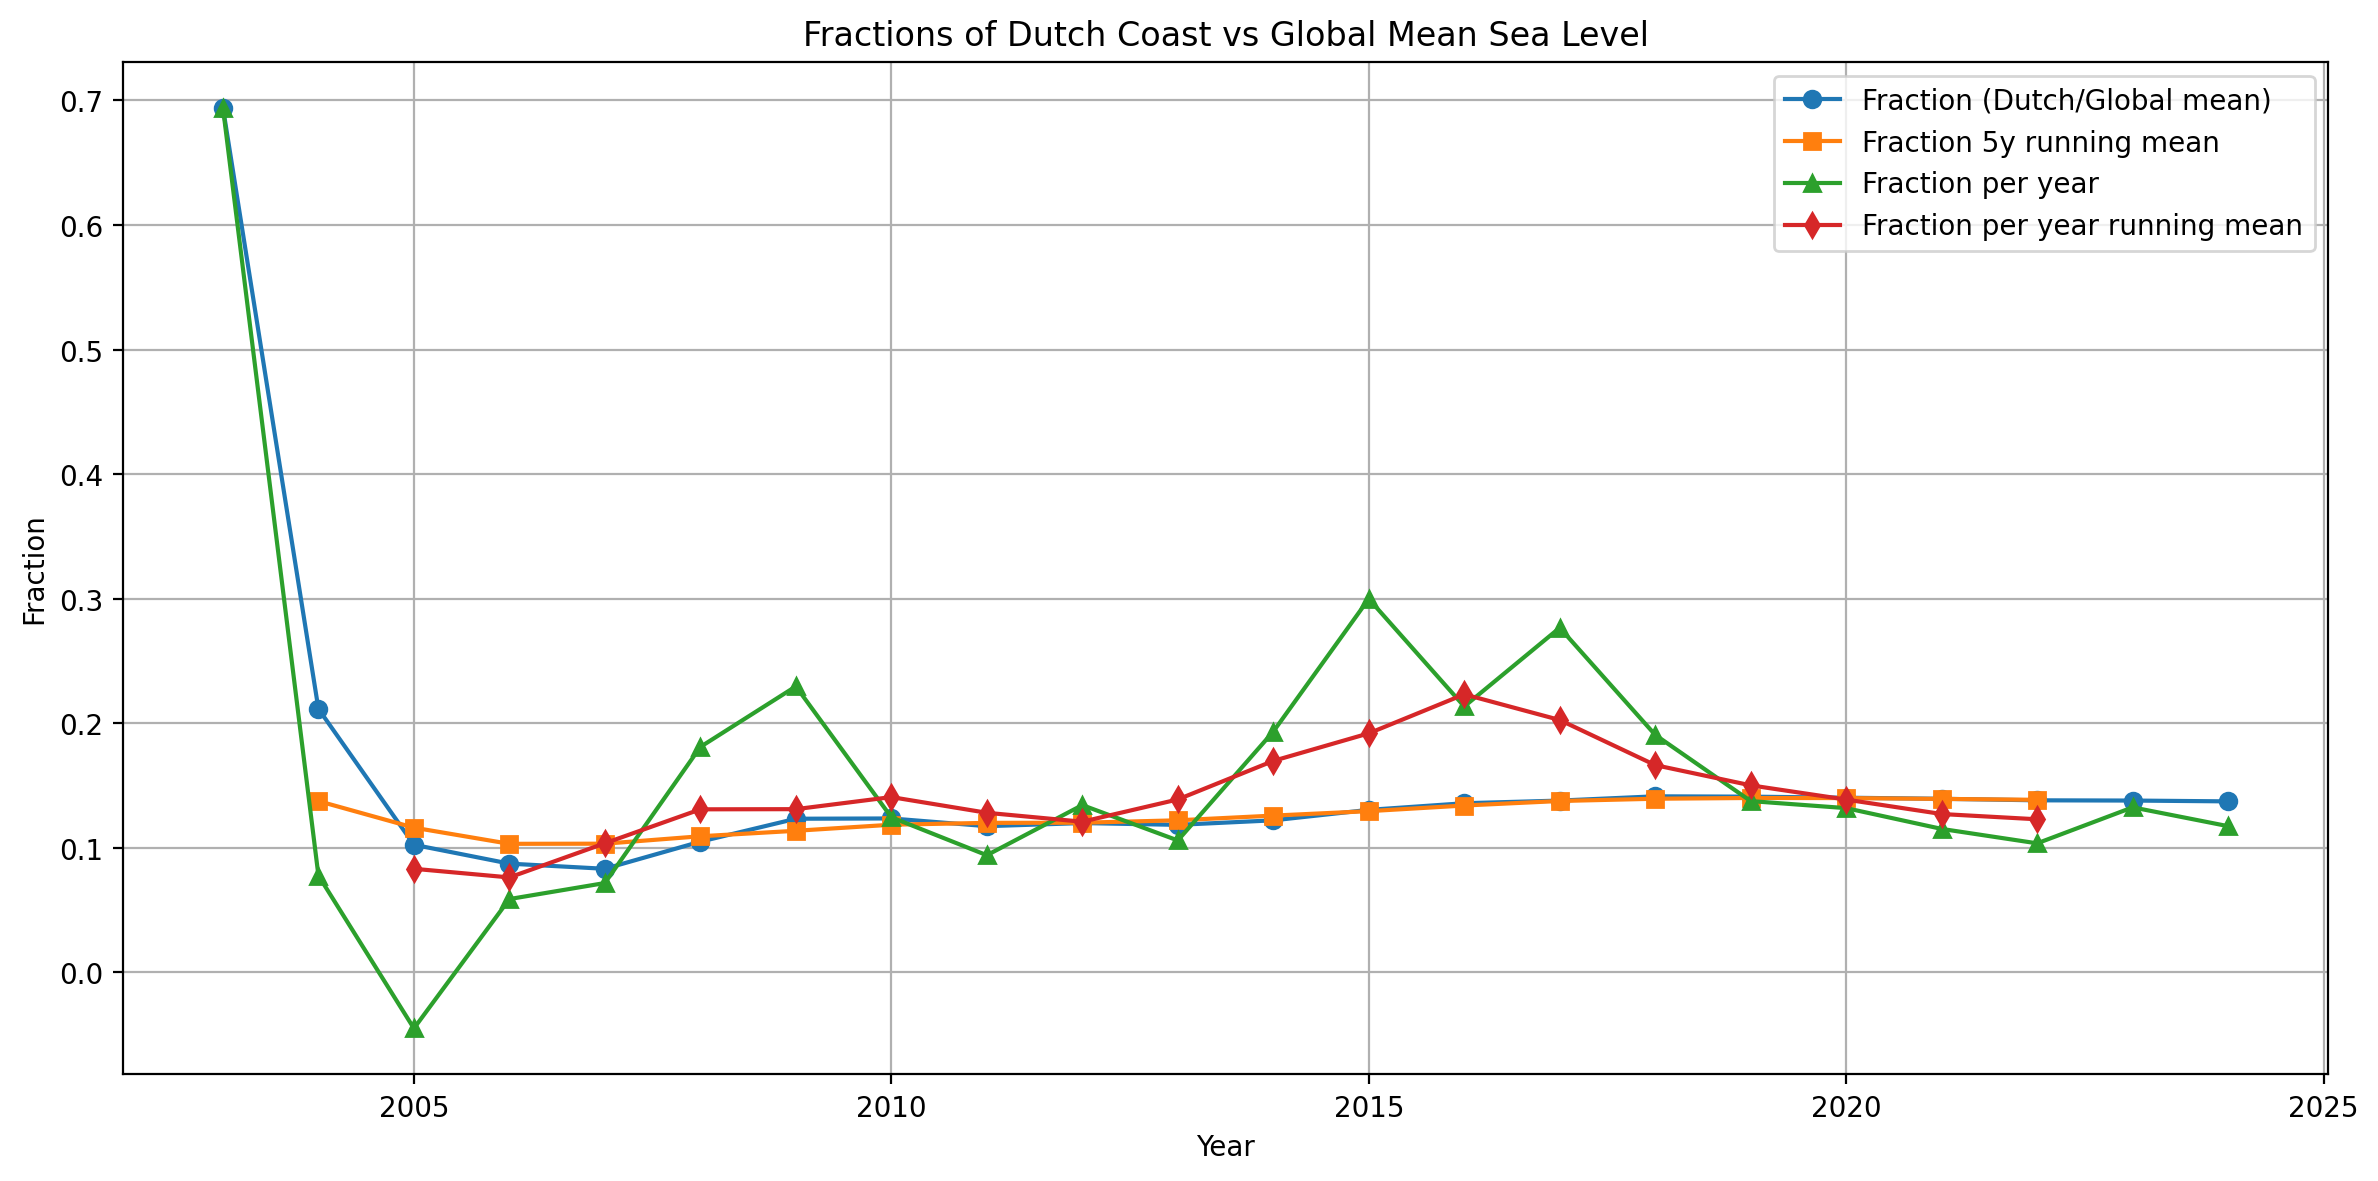

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot each fraction series
plt.plot(fraction.index, fraction, label='Fraction (Dutch/Global mean)', marker='o')
plt.plot(fraction_5y.index, fraction_5y, label='Fraction 5y running mean', marker='s')
plt.plot(fractionperyear.index, fractionperyear, label='Fraction per year', marker='^')
plt.plot(fractionperyearrun.index, fractionperyearrun, label='Fraction per year running mean', marker='d')

# Labels and title
plt.xlabel('Year')
plt.ylabel('Fraction')
plt.title('Fractions of Dutch Coast vs Global Mean Sea Level')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


In [23]:

dutch1 = dutch_coast.loc[2007] - dutch_coast.loc[2002] 
world1 = mean_world.loc[2007] - mean_world.loc[2002] 
frac1 = dutch1/world1
print(frac1) 

dutch2 = dutch_coast.loc[2014] - dutch_coast.loc[2009] 
world2 = mean_world.loc[2014] - mean_world.loc[2009] 
frac2 = dutch2/world2
print(frac2) 

dutch3 = dutch_coast.loc[2017] - dutch_coast.loc[2012] 
world3 = mean_world.loc[2017] - mean_world.loc[2012] 
frac3 = dutch3/world3
print(frac3)

dutch4 = dutch_coast.loc[2024] - dutch_coast.loc[2019] 
world4 = mean_world.loc[2024] - mean_world.loc[2019] 
frac4 = dutch4/world4
print(frac4)


0.08307502560878977
0.12086298836940189
0.19183005260163086
0.1228182421691712


(55, 36)


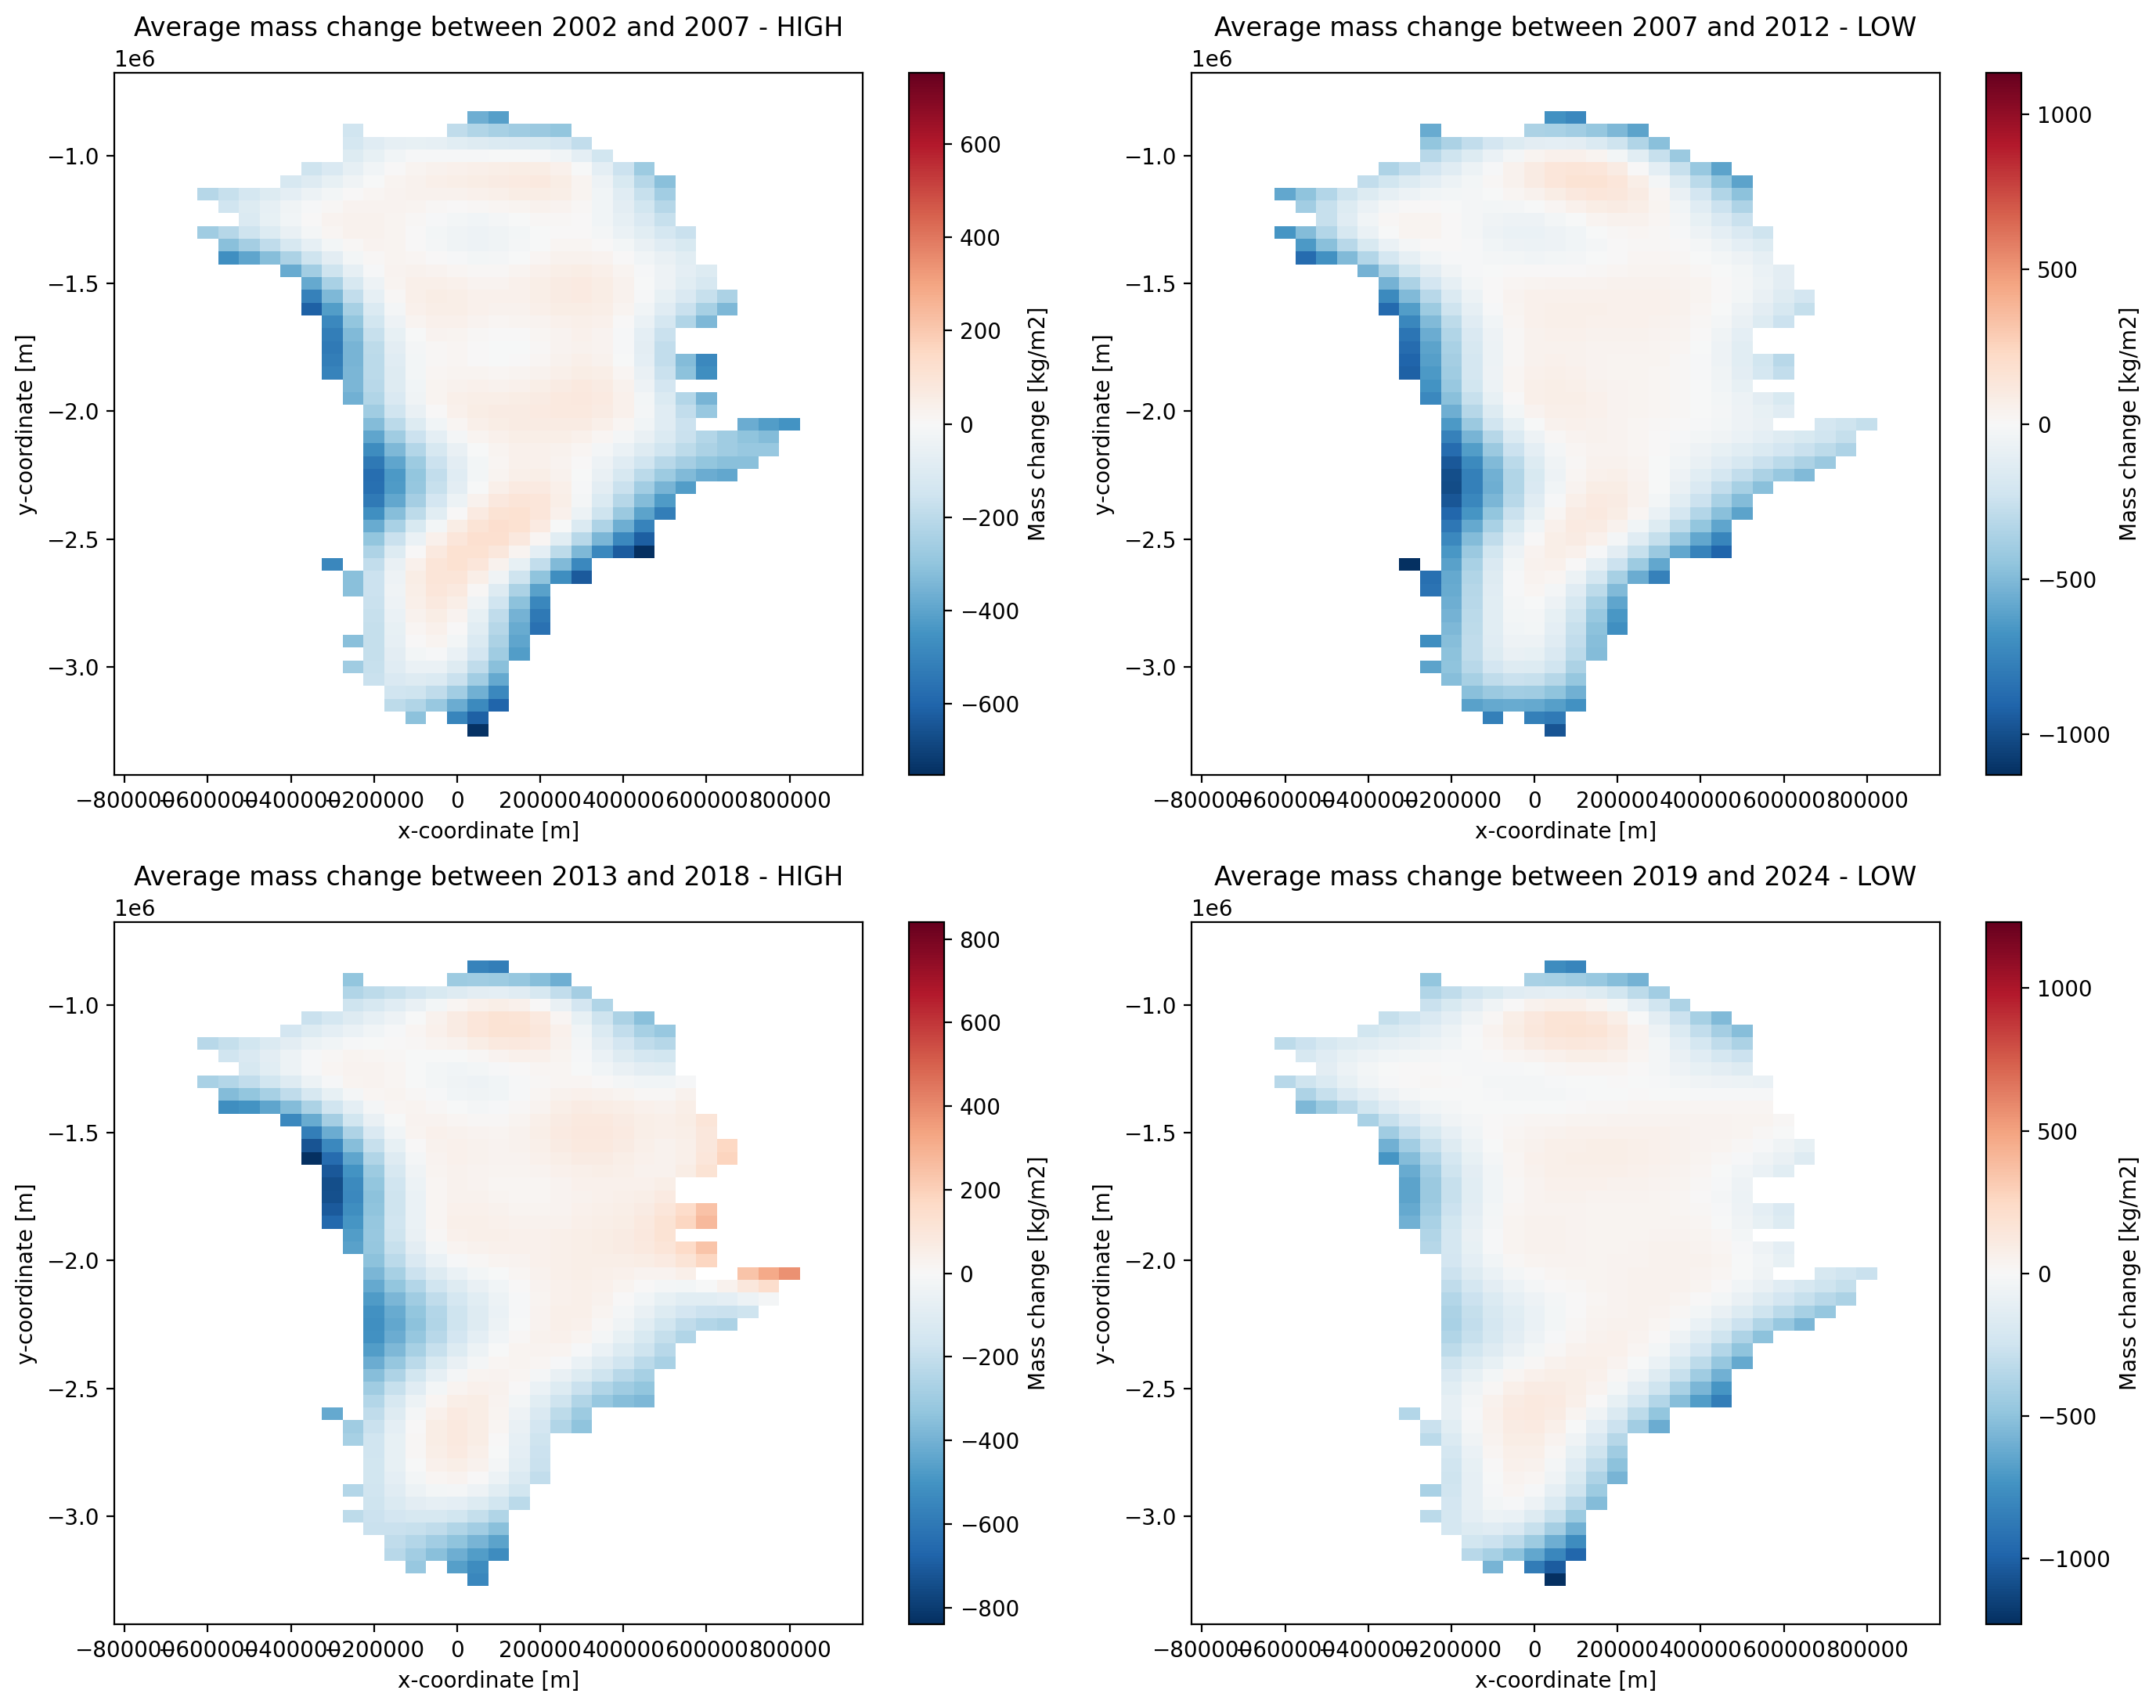

['2002-12-31T00:00:00.000000000' '2003-12-31T00:00:00.000000000'
 '2004-12-31T00:00:00.000000000' '2005-12-31T00:00:00.000000000'
 '2006-12-31T00:00:00.000000000' '2007-12-31T00:00:00.000000000'
 '2008-12-31T00:00:00.000000000' '2009-12-31T00:00:00.000000000'
 '2010-12-31T00:00:00.000000000' '2011-12-31T00:00:00.000000000'
 '2012-12-31T00:00:00.000000000' '2013-12-31T00:00:00.000000000'
 '2014-12-31T00:00:00.000000000' '2015-12-31T00:00:00.000000000'
 '2016-12-31T00:00:00.000000000' '2017-12-31T00:00:00.000000000'
 '2018-12-31T00:00:00.000000000' '2019-12-31T00:00:00.000000000'
 '2020-12-31T00:00:00.000000000' '2021-12-31T00:00:00.000000000'
 '2022-12-31T00:00:00.000000000' '2023-12-31T00:00:00.000000000'
 '2024-12-31T00:00:00.000000000']


In [24]:
#Plotjes maken: 
print(gre_y['dm'].sel(time='2002').squeeze().shape)

diff1 = gre_y['dm'].sel(time='2007').squeeze() - gre_y['dm'].sel(time='2002').squeeze()  # squeeze removes the time dimension (without dimension is (1,x,y) and now (x,y), with isel it is removed automatically. 
diff2 = gre_y['dm'].sel(time='2012').squeeze() - gre_y['dm'].sel(time='2007').squeeze()
diff3 = gre_y['dm'].sel(time='2018').squeeze() - gre_y['dm'].sel(time='2013').squeeze() 
diff4 = gre_y['dm'].sel(time='2024').squeeze() - gre_y['dm'].sel(time='2019').squeeze()

mean1 = diff1/5
mean2 = diff2/5
mean3 = diff3/5
mean4 = diff4/5


# plot the two difference figures
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))

# Plot the differences
mean1.plot(ax=ax1, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Mass change [kg/m2]'})
mean2.plot(ax=ax2, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Mass change [kg/m2]'})
mean3.plot(ax=ax3, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Mass change [kg/m2]'})
mean4.plot(ax=ax4, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Mass change [kg/m2]'})

# Add titles with fraction values
ax1.set_title(f'Average mass change between 2002 and 2007 - HIGH') #, fraction = {frac1.values:.4f}')
ax2.set_title(f'Average mass change between 2007 and 2012 - LOW') #, fraction = {frac2.values:.4f}')
ax3.set_title(f'Average mass change between 2013 and 2018 - HIGH') #, fraction = {frac3.values:.4f}')
ax4.set_title(f'Average mass change between 2019 and 2024 - LOW') # , fraction = {frac4.values:.4f}')


plt.tight_layout()
plt.show()

print(gre_y['time'].values)

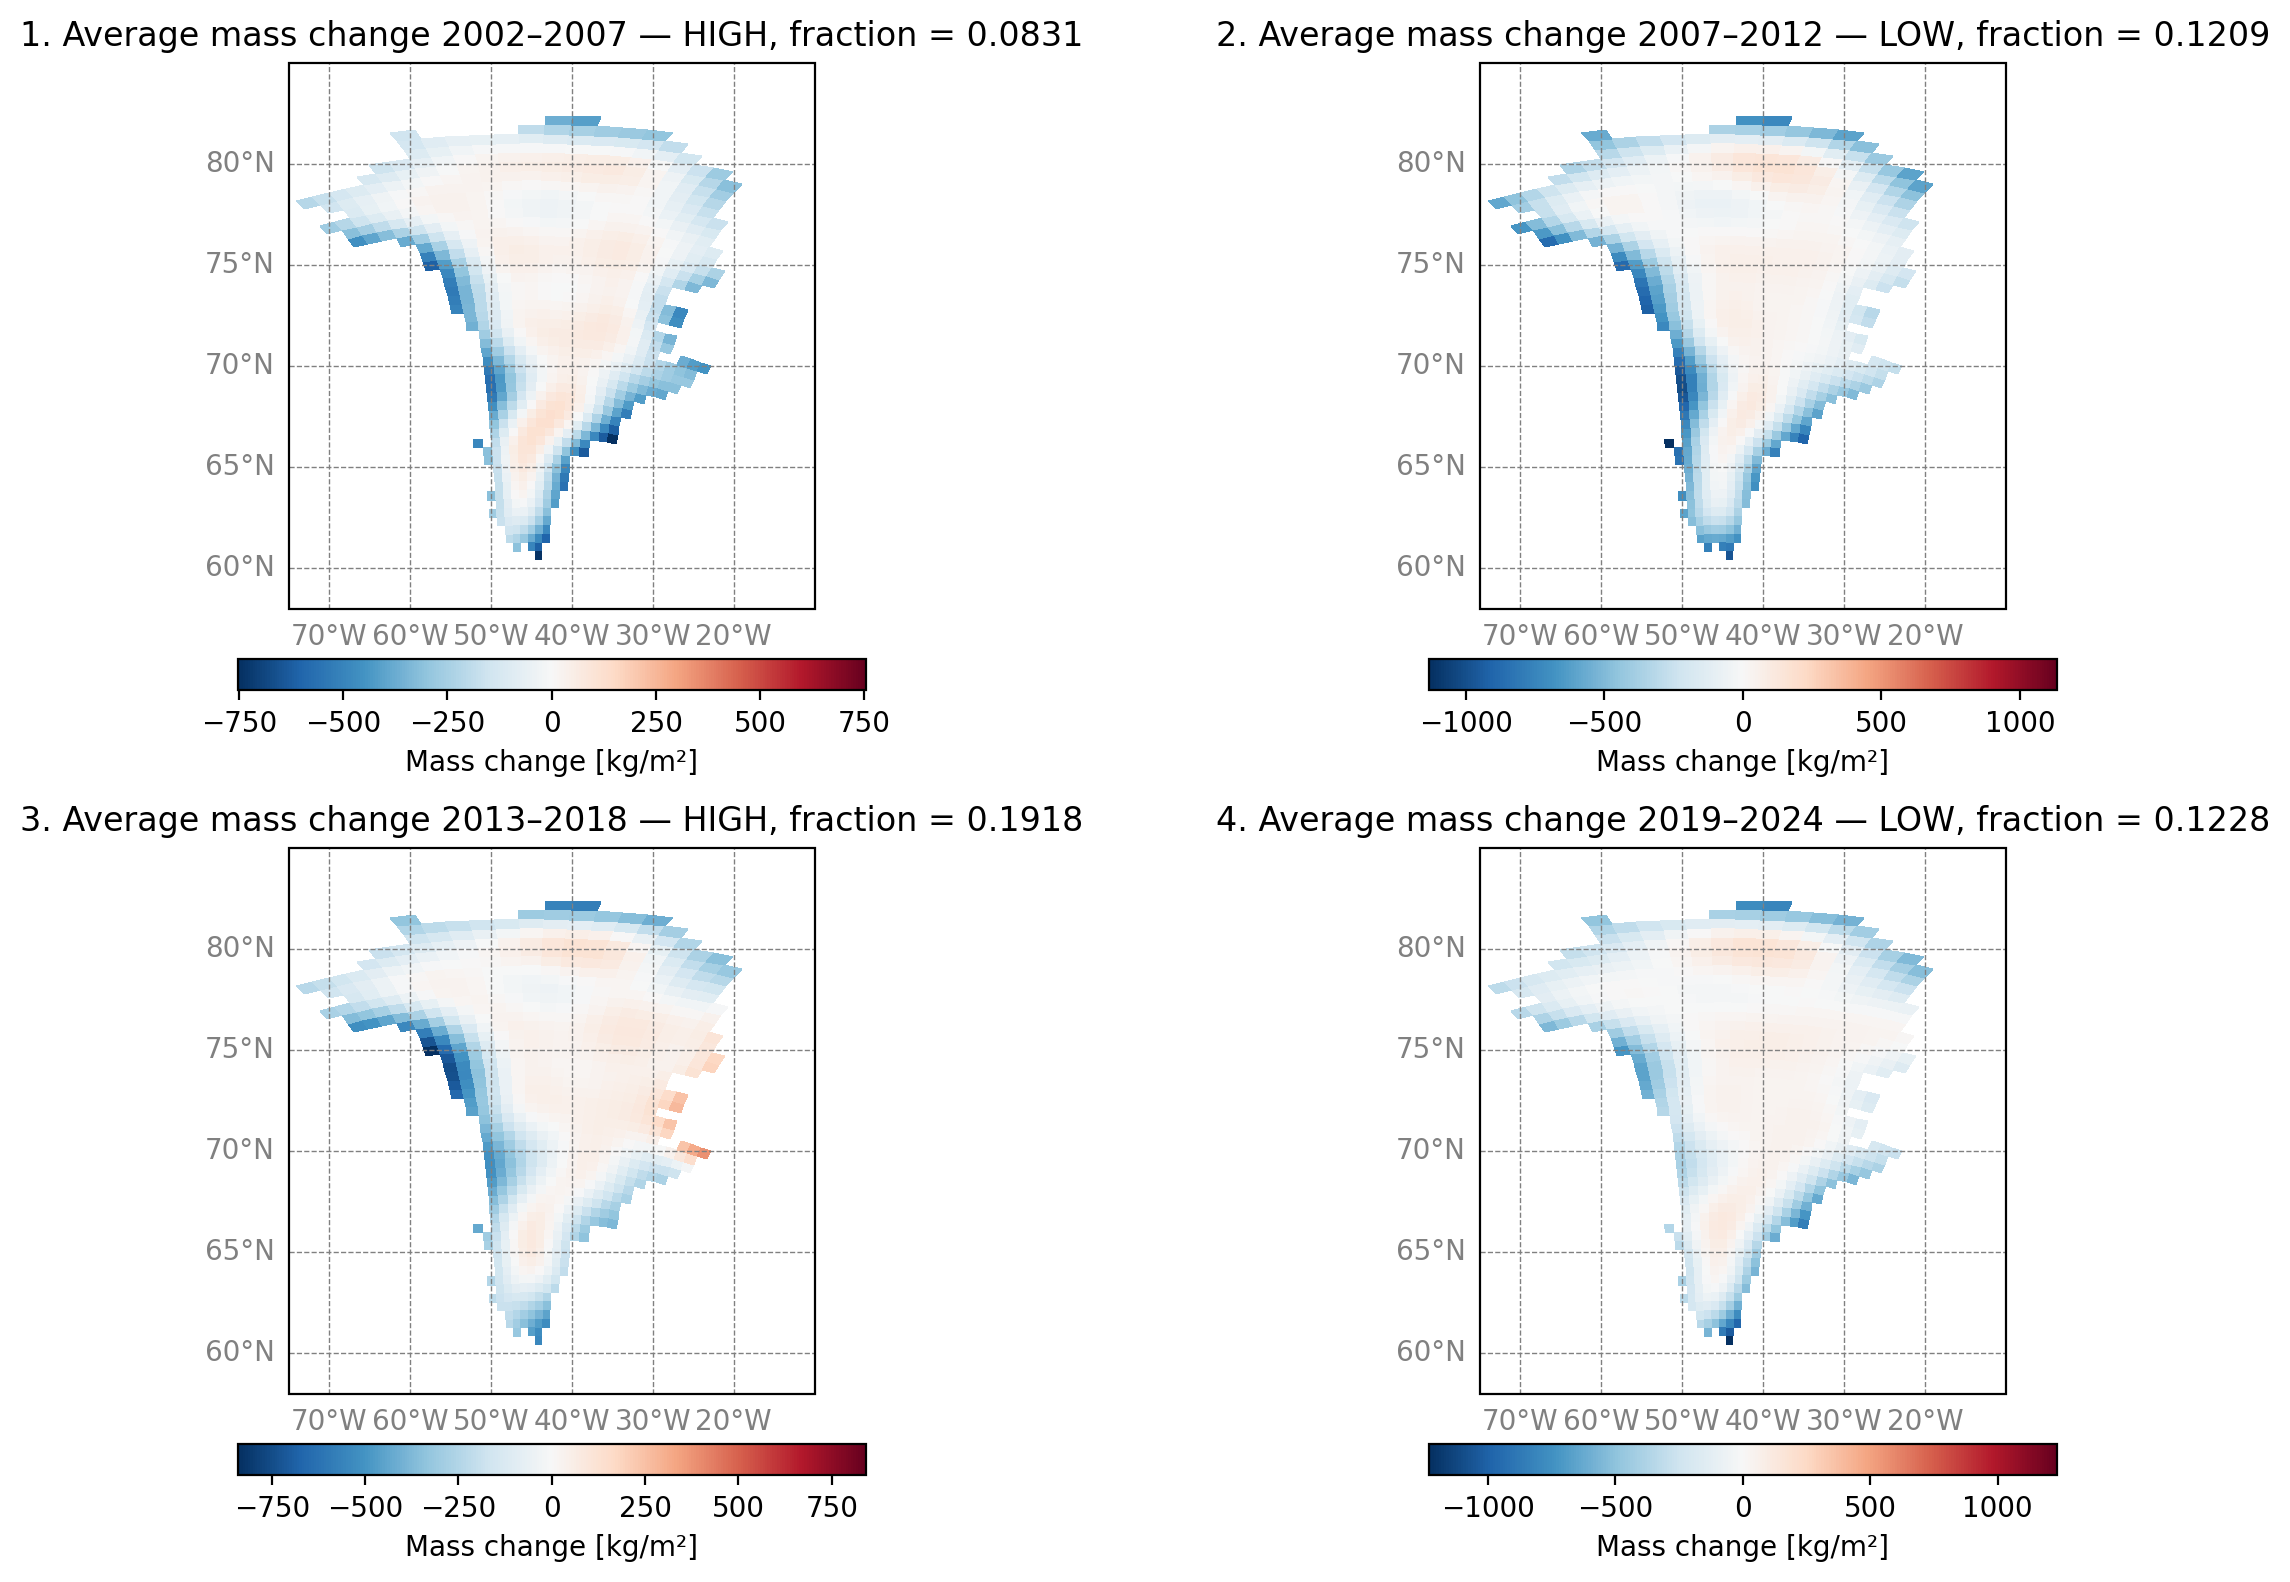

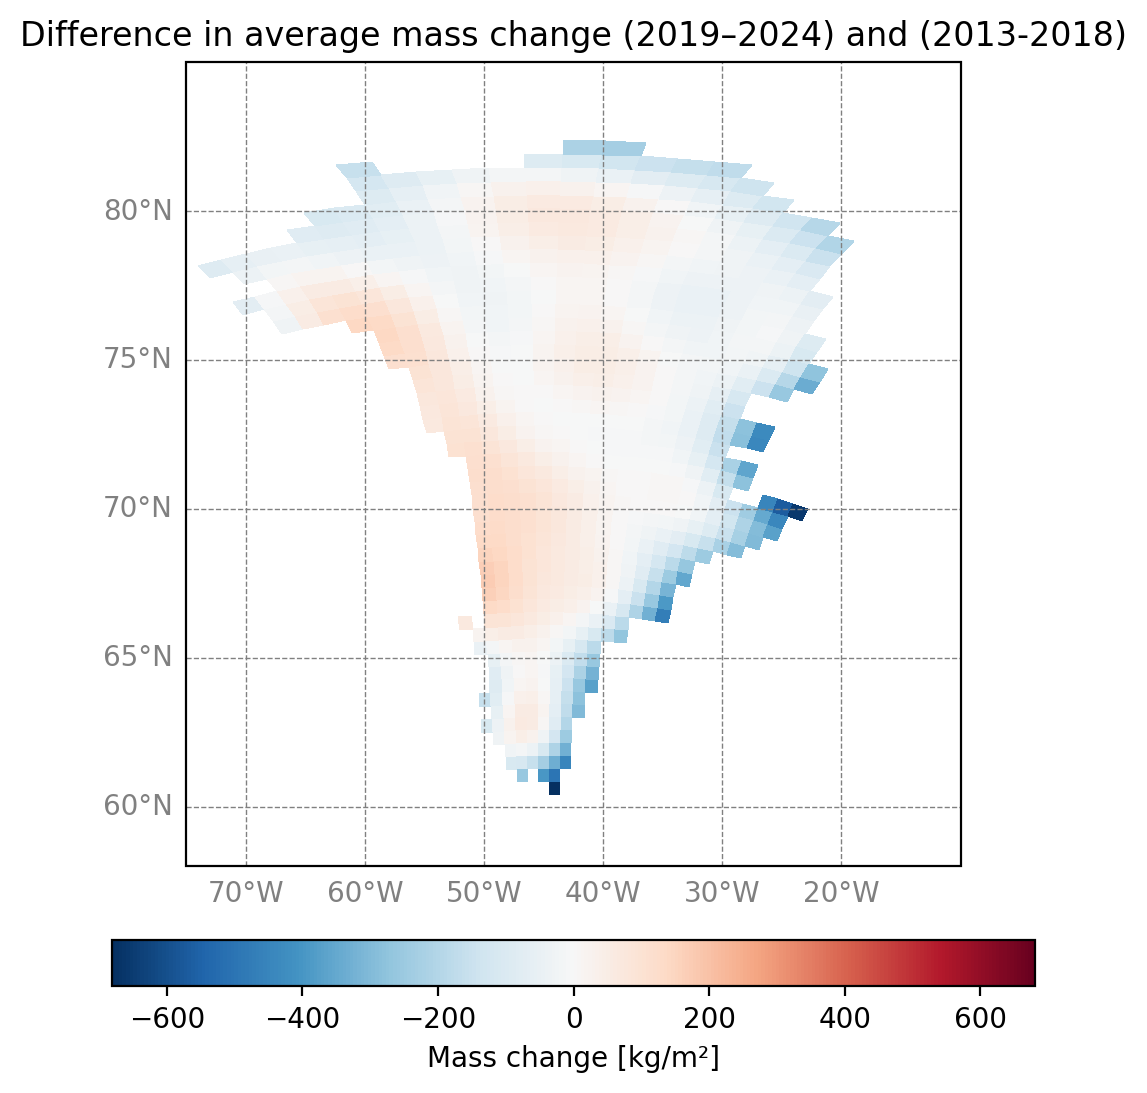

In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# lon/lat arrays
lon = gre_y['lon']
lat = gre_y['lat']

# ---- CREATE A TALLER FIGURE ----
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax1, ax2, ax3, ax4 = axes.flatten()
extent = [-75, -10, 58, 85] 

def plot_field(ax, data, title):
    absmax = np.nanmax(np.abs(data))
    vmin, vmax = -absmax, absmax

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    #ax.coastlines()
    gl = ax.gridlines(
        draw_labels=True,       # optional: show lat/lon labels
        linewidth=0.5,          # line thickness
        color='gray',           # color of gridlines
        linestyle='--'          # dashed style
    )

    # set the label colors to gray
    gl.top_labels = False      # usually top labels not needed
    gl.right_labels = False    # usually right labels not needed
    gl.xlabel_style = {'color': 'gray'}
    gl.ylabel_style = {'color': 'gray'}


    # >>> vertically stretch the map <<<
    ax.set_aspect(2.5)      # increase this number for more stretching

    mesh = ax.pcolormesh(
        lon, lat, data,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title)

    plt.colorbar(
        mesh, ax=ax,
        orientation='horizontal',
        pad=0.08,
        fraction=0.05,
        label='Mass change [kg/m²]'
    )


plot_field(ax1, mean1, f'1. Average mass change 2002–2007 — HIGH, fraction = {frac1:.4f}')
plot_field(ax2, mean2, f'2. Average mass change 2007–2012 — LOW, fraction = {frac2:.4f}')
plot_field(ax3, mean3, f'3. Average mass change 2013–2018 — HIGH, fraction = {frac3:.4f}')
plot_field(ax4, mean4, f'4. Average mass change 2019–2024 — LOW, fraction = {frac4:.4f}')



plt.tight_layout()
plt.show()


# Compute difference
diff = mean4 - mean3


# Create a single figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot using the same function
plot_field(ax, diff, f'Difference in average mass change (2019–2024) and (2013-2018)')

plt.show()



